## 环境测试

In [1]:
import tensorflow as tf
m1 = [[2,2]]
m2 = [[3],[3]]
dot_product = tf.matmul(m1, m2)
print(dot_product)

# 会话
sess = tf.Session()
result = sess.run(dot_product)
print(result)
sess.close()

Tensor("MatMul:0", shape=(1, 1), dtype=int32)
[[12]]


## 变量初始化

In [ ]:
import tensorflow as tf

# 变量
var = tf.Variable(0)

# 加法操作
add_result = tf.add(var, 100)

# 会话，使用with语句会自动关闭会话
with tf.Session() as sess:
    # 必须先初始化变量
    sess.run(var.initializer)
    print(sess.run(add_result))

100


## 使用列表进行批量运行

In [2]:
import tensorflow as tf
input1 = 2.0
input2 = 3.0
input3 = 4.0
intermed = tf.add(input2, input3)
mul = tf.multiply(input1, intermed)
with tf.Session() as sess:
    result = sess.run([mul, intermed])
    print(result)

[14.0, 7.0]


## 

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.05050505 0.15151515 0.25252525 0.35353535
 0.45454545 0.55555556 0.65656566 0.75757576 0.85858586 0.95959596
 1.06060606 1.16161616 1.26262626 1.36363636 1.46464646 1.56565657
 1.66666667 1.76767677 1.86868687 1.96969697 2.07070707 2.17171717
 2.27272727 2.37373737 2.47474747 2.57575758 2.67676768 2.77777778
 2.87878788 2.97979798 3.08080808 3.18181818 3.28282828 3.38383838
 3.48484848 3.58585859 3.68686869 3.78787879 3.88888889 3.98989899
 4.09090909 4.19191919 4.29292929 4.39393939 4.49494949 4.5

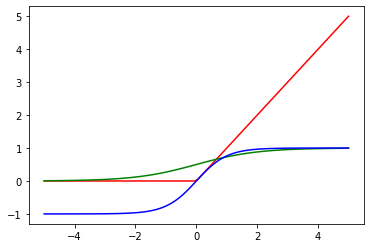

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
x = np.linspace(-5, 5, 100)
y_relu = tf.nn.relu(x)# ReLU函数
y_sigmoid = tf.nn.sigmoid(x)# Sigmoid函数
y_tanh = tf.nn.tanh(x)# Tanh函数

sess = tf.Session()
y_relu, y_sigmoid, y_tanh = sess.run([y_relu, y_sigmoid, y_tanh])#解包
print(y_relu)
print(x)
plt.plot(x, y_relu, label='ReLU', color='r')
plt.plot(x, y_sigmoid, label='Sigmoid', color='g')
plt.plot(x, y_tanh, label='Tanh', color='b')

plt.show()
sess.close()


## 占位符

In [7]:
#静态的数据流图placeholder  占位
import tensorflow as tf
x1 = tf.placeholder(dtype = tf.float32)
y1 = tf.placeholder(dtype = tf.float32)
z1 = x1 + y1
x2 = tf.placeholder(dtype = tf.float32)
y2 = tf.placeholder(dtype = tf.float32)
z2 = tf.matmul(x2, y2)

with tf.Session() as sess:
    z1_values = sess.run(z1, feed_dict={x1: 3.0, y1: 4.0})#实际值
    z2_values = sess.run(z2, feed_dict={x2: [[2],[4]], y2: [[5,6]]})
    
print(z1_values)
print(z2_values)

7.0
[[10. 12.]
 [20. 24.]]


## 使用tensorflow搭建神经网络

In [3]:
import tensorflow as tf
import numpy as np

from tensorflow.examples.tutorials.mnist import input_data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
# 数据预处理
x_train = x_train.reshape(-1, 784) / 255.0  # 将28x28的图像展平为784维的向量，并归一化到[0, 1]范围
x_test = x_test.reshape(-1, 784) / 255.0
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)  # 将标签转换为one-hot编码
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

# 将数据集展平为784维的向量
inputX = tf.placeholder(tf.float32, [None, 784], name='inputX') # 28*28
outputY = tf.placeholder(tf.float32, [None, 10], name='outputY') # 0-9 10个数字

# 卷积神经网络需要4维的张量，分别是[样本数量，宽度，高度，通道数]
# 因为是灰度图，所以通道数是1，如果是彩色图像，通道数是3
inputX_image = tf.reshape(inputX, [-1, 28, 28, 1]) # -1表示不确定的数量，1表示单通道

# 取前1000个测试样本进行测试
testX = x_test[:1000]
testY = y_test[:1000]

# 搭建卷积神经网络
# 第一层卷积层，5x5的卷积核，1个输入通道，32个输出通道
# 输出的形状是[?, 28, 28, 32]
conv1 = tf.layers.conv2d(
    inputs = inputX_image,  # 输入数据
    filters = 32,   # 输出通道数
    kernel_size = [5, 5],   # 卷积核大小5x5
    strides = 1,    # 步长为1
    padding = 'same', # same表示输出和输入的尺寸一样;valid表示不一样
    activation = tf.nn.relu # 激活函数使用ReLU
) 

# 第一层池化层，2x2的池化核，步长为2
# 输出的形状是[?, 14, 14, 32]
pool1 = tf.layers.max_pooling2d(
    inputs = conv1,
    pool_size = [2, 2],
    strides = 2
) 

# 第二层卷积层，5x5的卷积核，32个输入通道，64个输出通道
conv2 = tf.layers.conv2d(
    inputs = pool1,
    filters = 64,
    kernel_size = [5, 5],
    strides = 1,
    padding = 'same',
    activation = tf.nn.relu
)
# 第二层池化层，2x2的池化核，步长为2
# 输出的形状是[?, 7, 7, 64]
pool2 = tf.layers.max_pooling2d(
    inputs = conv2,
    pool_size = [2, 2],
    strides = 2
)

# 将第四维度展开
# 7*7*64=3136
flat = tf.reshape(pool2, [-1, 7*7*64])

# 全连接层，1024个神经元
fc1 = tf.layers.dense(
    inputs = flat,
    units = 1024,
    activation = tf.nn.relu
)

# Dropout层，防止过拟合
dropout = tf.layers.dropout(
    inputs = fc1,
    rate = 0.5
)

# 输出层，10个神经元，对应10个类别
logits = tf.layers.dense(
    inputs = dropout,
    units = 10
)

# 计算误差
loss = tf.losses.softmax_cross_entropy(
    onehot_labels=outputY, logits=logits
)

# 使用梯度下降，取降低交叉熵
train_op = tf.train.AdadeltaOptimizer(0.1).minimize(loss)

# 计算精度（局部变量）
accuracy = tf.metrics.accuracy(
    labels=tf.argmax(outputY, axis=1),
    predictions=tf.argmax(logits, axis=1)
)[1]    # 返回精度值

# 初始化全局变量和局部变量
init = tf.group(tf.global_variables_initializer(), tf.local_variables_initializer())

# 训练模型,进行会话操作
with tf.Session() as sess:
    sess.run(init)
    for epoch in range(1000):
        batch_x = x_train[epoch*100:(epoch+1)*100]
        batch_y = y_train[epoch*100:(epoch+1)*100]
        train_loss, op = sess.run([loss, train_op],{inputX:batch_x, outputY:batch_y})
        if epoch % 100 == 0:
            test_acc = sess.run(accuracy, {inputX:testX, outputY:testY})
            print("训练轮次：%d, 损失值：%.4f, 测试集精度：%.2f%%" % (epoch, train_loss, test_acc*100))
    print("训练完成！")

训练轮次：0, 损失值：2.3035, 测试集精度：12.80%
训练轮次：100, 损失值：0.6841, 测试集精度：44.30%
训练轮次：200, 损失值：0.4642, 测试集精度：58.87%
训练轮次：300, 损失值：0.3105, 测试集精度：66.70%
训练轮次：400, 损失值：0.2173, 测试集精度：71.74%
训练轮次：500, 损失值：0.2090, 测试集精度：75.18%
训练轮次：600, 损失值：0.0000, 测试集精度：77.67%
训练轮次：700, 损失值：0.0000, 测试集精度：79.54%
训练轮次：800, 损失值：0.0000, 测试集精度：80.99%
训练轮次：900, 损失值：0.0000, 测试集精度：82.15%
训练完成！


In [14]:
import tensorflow as tf
import numpy as np

# 1. 加载数据
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print("训练数据集的数量：", x_train.shape)

# 2. 数据预处理
# 归一化到 [0, 1] 范围
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# 将标签转换为 one-hot 编码
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# 3. 取前1000个测试样本进行测试
testX = x_test[:1000]
testY = y_test[:1000]

# 4. 搭建卷积神经网络（使用 Keras Sequential API）
model = tf.keras.Sequential([
    # 输入层：需要将数据重塑为 [批次, 28, 28, 1]
    tf.keras.layers.Reshape((28, 28, 1), input_shape=(28, 28)),
    
    # 第一层卷积层
    tf.keras.layers.Conv2D(
        filters=32,               # 32个输出通道
        kernel_size=(5, 5),       # 5x5卷积核
        strides=1,                # 步长为1
        padding='same',           # 保持输出尺寸不变
        activation='relu',        # ReLU激活函数
        name='conv1'              # 层名称
    ),
    
    # 池化层
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    
    # 第二层卷积层
    tf.keras.layers.Conv2D(
        filters=64, 
        kernel_size=(5, 5), 
        padding='same', 
        activation='relu'
    ),
    
    # 池化层
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    
    # 展平层
    tf.keras.layers.Flatten(),
    
    # 全连接层
    tf.keras.layers.Dense(1024, activation='relu'),
    
    # Dropout层防止过拟合
    tf.keras.layers.Dropout(0.5),
    
    # 输出层
    tf.keras.layers.Dense(10, activation='softmax')
])

# 5. 编译模型
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 6. 查看模型结构
model.summary()

# 7. 训练模型
model.fit(x_train, y_train, 
          batch_size=128, 
          epochs=5, 
          validation_split=0.2)

# 8. 评估模型
test_loss, test_acc = model.evaluate(testX, testY)
print(f'\n测试准确率: {test_acc:.4f}')

训练数据集的数量： (60000, 28, 28)
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
reshape_1 (Reshape)          (None, 28, 28, 1)         0         
_________________________________________________________________
conv1 (Conv2D)               (None, 28, 28, 32)        832       
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 14, 14, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 14, 14, 64)        51264     
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 7, 7, 64)          0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 3136)              0         
_________________________________________________________________
dense_1 (Dense)              (None, 1024)         